# COGS 108 - EDA Checkpoint

## Authors
- Michelle Ma: EDA Visualizations and supplemental commentary for Dataset 2 & Updating Hypothesis/Research Question
- Yves Mojica:  Calculations and Commentary for both Datasets
- Edgar Seecof: Cleaning and fixing dataset 1
- Travon Williams: EDA Visualizations for Dataset 1
- Felix Xie: Cleaning and fixing dataset 2

# Research Question

To what extent does early academic performance predict student dropout among students in the Portuguese and Spanish higher education institutions? Specifically, using students’ first-year GPA, course completion rates, and credit accumulation as predictors, can we model the probability that a student drops out within one year within these institutional contexts?

# Background and Prior Work

Predicting student dropout in higher education has become a prevalent topic in educational research because early identification of at-risk students can enable universities and colleges to proactively support their students and try to prevent them leaving the college. Student attrition is a large loss to higher education institutions, as it represents lost tuition revenue, reduced completion metrics that reflect poorly on the institution itself, and an inefficient allocation of resources. Arguably, it is sometimes worse off for students, who may incur financial debt, delayed career entry, and negative psychological consequences from leaving college early. At a higher societal level, dropout undermine the workforce and its development, and only further education and economic inequality. 

This understanding has motivated more and more work to help model student dropout risk using early academic data, serving as a basis for data driven intervention strategies to help mitigate these fallbacks of dropout. Previous research suggests that much of dropout experienced in the first years of college, and is related to students' academic performance early on in their education as it could affect their belief in their academic fit and future success. This is believed to be because early academic success and/or failures act as a feedback loop to update student beliefs in their own abilities. Furthermore, when students fail to meet expectations early on, their assessment of whether or not higher education is a worthwhile financial investment is also called into question, leading to a higher chance of dropout.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1)

Building on this theoretical research, researchers in educational data mining have this task of dropout prediction as a supervised machine learning problem. Studies applying traditional ML classification models such as logistic regression, decision trees, and boosting methods have found that academic performance serves as a relatively consistent predictor of dropout (as a binary classification task), amplified when the scope is purely on the first year of dropout. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2). This study highlights the feasibility of utilizing a more traditional ML approach to accurately map out dropout rates, and motivates us to focus on early academic indicators. 

Expanding on this, a similar paper from UCI expands this to a multi-class classification task, adding three labels: graduated, dropped out, or still continuing the degree after the expected amount of time. They found similar results, arguing that early academic performance is a consistent predictor of student outcomes, but they also note that many other factors and variable do play a role, for example one being their financial situation and socioeconomic status. <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). This study provides both a validated and cleaned dataset as well as a methodological reference point for modeling dropout. 

1. <a name="cite_note-1"></a> Stinebrickner, T., & Stinebrickner, R. (2014). A major in science? Initial beliefs and final outcomes for college major and dropout. NBER Working Paper No. 18945. https://www.nber.org/papers/w18945
2. <a name="cite_note-2"></a> Lakkaraju, H., Aguiar, E., Shan, C., Miller, D., Bhanpuri, N., Ghani, R., & Addison, K. (2015). A machine learning framework to identify students at risk of adverse academic outcomes. Proceedings of the 21st ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. https://dl.acm.org/doi/10.1145/2783258.2788620
3. <a name="cite_note-3"></a> Martins, M. V., Tolledo, D., Oliveira, J., & Gonçalves, R. (2021). Early prediction of student’s performance in higher education: A case study. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Predict+Students+Dropout+and+Academic+Success

# Hypothesis


We hypothesize that there will be a correlation between early academic performance of a student during their first year of university and the likelihood of dropping out. Specifically, we define poor early academic performance using measurable indicators including lower first-year GPA, lower pass rate, and fewer total credits passed. For example, we can classify lower GPAs and pass rates as those in the bottom quartile of our data. Students who meet one or more of these criteria are expected to have a higher probability of dropping out compared to students who meet standard academic progress benchmarks. However, we anticipate that this relationship will be moderate rather than strong, as academic performance alone is unlikely to fully explain dropout. Other factors such as socioeconomic background, nationality, scholarship status, and more may have an equal or greater influence, but these varaibles are out of the scope of our analysis.

## Data 

### Data Wrangling

In [1]:
# Imports and Setup
import pandas as pd
import numpy as np
import os

RAW_DATA_DIR = 'data/00-raw/'
INT_DATA_DIR = 'data/01-interim/'
PROCESSED_DATA_DIR = 'data/02-processed/'

In [5]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [6]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    {
        'url': 'https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip',
        'filename': 'predict_students_dropout.zip'
    },
    { 
        'url': 'https://zenodo.org/records/17239943/files/dataset_2022_hash.zip?download=1', 
        'filename':'university_dropout_2022.zip'
    }, # Decompressed later using pd.read_csv
    { 
        'url': 'https://zenodo.org/records/17239943/files/dataset_2021_hash.zip?download=1', 
        'filename':'university_dropout_2021.zip'
    } , # Decompressed later using pd.read_csv
    { 
        'url': 'https://zenodo.org/records/17239943/files/dataset_2018_hash.zip?download=1', 
        'filename':'university_dropout_2018.zip'
    } # Decompressed later using pd.read_csv
]
get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:   0%|          | 0/4 [00:00<?, ?it/s]
                                                             

Successfully downloaded: predict_students_dropout.zip



Overall Download Progress:  50%|█████     | 2/4 [00:05<00:05,  2.64s/it]                     

Successfully downloaded: university_dropout_2022.zip



Overall Download Progress:  75%|███████▌  | 3/4 [00:07<00:02,  2.63s/it]                     

Successfully downloaded: university_dropout_2021.zip



Overall Download Progress: 100%|██████████| 4/4 [00:10<00:00,  2.63s/it]                     

Successfully downloaded: university_dropout_2018.zip


### Students’ Dropout and Academic Success dataset (Dataset 1)


Work related to the cleaning up and fixing of mistakes made during the data checkpoint for our first dataset

In [7]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

In [2]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## 3.A LOAD DATASET
data1 = pd.read_csv(
    f'{RAW_DATA_DIR}predict_students_dropout.zip',
    sep=';',
    compression='zip' # Webpage download default as .zip
)

In [3]:
## 3.B MAKE TIDY OR SHOW TIDY
data1.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
## 3.C DEMONSTRATE SIZE OF DATASET
print("Dataset shape (rows, columns):", data1.shape)
data1.dtypes

Dataset shape (rows, columns): (4424, 37)


Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

**This data set was already used for more formal projects and has already been cleaned of missing values.**

In [5]:
## 3.D FIND OUT HOW MUCH DATA IS MISSING AND WHERE
col_missing_count = data1.isnull().sum()
total_missing_count = col_missing_count.sum()
total_missing_count
print(f"There are {total_missing_count} missing values.")

There are 0 missing values.


In [6]:
## 3.E FIND AND FLAG ANY OUTLIERS OR SUS ENTRIES
numeric_cols = data1.select_dtypes(include = ['number']).columns
outliers = pd.DataFrame(index = data1.index)
## iterate accross all numeric columns and find outliers and store in outliers df
for col in numeric_cols:
    ##https://stackoverflow.com/questions/23228244/how-do-you-find-the-iqr-in-numpy
    q75, q25 = np.nanpercentile(data1[col], [75, 25])
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers[f'{col}_outlier'] = (data1[col] < lower_bound) | (data1[col] > upper_bound)

print('Number of outliers in each column')
print(outliers.sum())

Number of outliers in each column
Marital status_outlier                                     505
Application mode_outlier                                     0
Application order_outlier                                  541
Course_outlier                                             442
Daytime/evening attendance\t_outlier                       483
Previous qualification_outlier                             707
Previous qualification (grade)_outlier                     179
Nacionality_outlier                                        110
Mother's qualification_outlier                               0
Father's qualification_outlier                               0
Mother's occupation_outlier                                182
Father's occupation_outlier                                177
Admission grade_outlier                                     86
Displaced_outlier                                            0
Educational special needs_outlier                           51
Debtor_outlier       

**This data is already very clean, no missing values or ridiculous outliers, the only thing that we may have to change is the data types being used for certain variables**

In [7]:
## 3.F CLEAN THE DATA
if data1.isna().sum().sum() == 0:
    print('No missing values')
else: 
    print(f'There are {data1.isna().sum().sum()} missin values')

No missing values


In [8]:
## Next need to remove columns that we do not need
cols_to_drop = [
    'Marital status',  # Demographics
    'Application mode', # Application related
    'Application order', # Application related
    'Course', # Student "Major"
    'Daytime/evening attendance\t', # Unnecessary and no equivalent in data2_2022
    'Previous qualification', # Students highest level of education
    'Nacionality', # Demographics
    "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", # Family Demographics
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', # Unnecessary Student demographics
    'Age at enrollment', 'International', # Unnecessary Student demographics
    'Unemployment rate', 'Inflation rate', 'GDP', # Portugal Economic Data
]

data1 = data1.drop(columns = cols_to_drop, errors = 'ignore')

In [9]:
## Then remove rows where enrolled credits are 0
data1 = data1.loc[(data1['Curricular units 1st sem (enrolled)'] != 0) & (data1['Curricular units 2nd sem (enrolled)'] != 0)]

In [10]:
## Mapping 'Target' to numerical values
target_map = {
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
}

data1['Target_Numeric'] = data1['Target'].map(target_map)
print(data1[['Target', 'Target_Numeric']].head(100))
## Target_numeric now shows the outcome as an integer

       Target  Target_Numeric
1    Graduate               2
2     Dropout               0
3    Graduate               2
4    Graduate               2
5    Graduate               2
..        ...             ...
102   Dropout               0
103  Graduate               2
104   Dropout               0
105  Graduate               2
106   Dropout               0

[100 rows x 2 columns]


In [11]:
## Renaming cols to something that makes more sense
name_map = {
    # 1st Sem
    'Curricular units 1st sem (enrolled)': 'Sem1_Enrolled', # Credits Enrolled 
    'Curricular units 1st sem (credited)': 'Sem1_Credited', # Transfer credits
    'Curricular units 1st sem (approved)': 'Sem1_Passed', # Classes passed
    'Curricular units 1st sem (grade)': 'Sem1_Gpa',
    'Curricular units 1st sem (evaluations)': 'Sem1_Evaluations', # Classes where student took an exam
    'Curricular units 1st sem (without evaluations)': 'Sem1_Skipped', # Classes stopped attending/skipped

    # 2nd Sem
    'Curricular units 2nd sem (enrolled)': 'Sem2_Enrolled',
    'Curricular units 2nd sem (credited)': 'Sem2_Credited',
    'Curricular units 2nd sem (approved)': 'Sem2_Passed',
    'Curricular units 2nd sem (grade)': 'Sem2_Gpa',
    'Curricular units 2nd sem (evaluations)': 'Sem2_Evaluations',
    'Curricular units 2nd sem (without evaluations)': 'Sem2_Skipped'
}

data1 = data1.rename(columns = name_map)

In [12]:
## 3.G MOVE TO PROCESSED
data1_clean = data1.copy()
processed_path = os.path.join(PROCESSED_DATA_DIR, 'predict_students_dropout_clean.csv')
data1_clean.to_csv(processed_path, index=False, sep = ';')

In [13]:
## 4. SUMMARY STATISTICS
data1_clean.describe()
data1_clean.head(100)

,Previous qualification (grade),Admission grade,Gender,Sem1_Credited,Sem1_Enrolled,Sem1_Evaluations,Sem1_Passed,Sem1_Gpa,Sem1_Skipped,Sem2_Credited,Sem2_Enrolled,Sem2_Evaluations,Sem2_Passed,Sem2_Gpa,Sem2_Skipped,Target,Target_Numeric
1,160.0,142.5,1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate,2
2,122.0,124.8,1,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout,0
3,122.0,119.6,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate,2
4,100.0,141.5,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate,2
5,133.1,114.8,1,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,Graduate,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,130.0,113.5,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout,0
103,133.1,160.0,0,13,18,19,18,14.631579,0,10,13,14,13,14.230769,1,Graduate,2
104,123.0,117.4,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout,0
105,130.0,122.2,0,4,10,12,10,13.000000,0,5,11,11,11,12.272727,0,Graduate,2


### University Student Dropout Dataset (Dataset 2)

The University Student Dropout dataset is organized as yearly CSV files named dataset_{year}.csv, with each row corresponding to a student-course enrollment for that academic year. Each file integrates data from four sources: students, programs, courses, and digital logs, and also groups variables into six thematic categories: context, admission pathways, socio-economic and demographic background, academic data, digital logs, and Wi-Fi access. Contextual attributes include anonymized identifiers for students, courses, academic programs, and campuses, as well as the academic year and group IDs, capturing where and how each student is enrolled. Admission pathway variables describe how the student entered the university, including year of enrollment, type of admission, entry exam grades (scaled to 10 or 14), and program selection preference. Socioeconomic and demographic variables capture parental education, student dedication to studies, and whether the student had to move provinces to attend university, providing insight into economic or social challenges that might affect retention.

Academic data is the most detailed category, including grades, credits enrolled and earned across multiple years, semester performance, adjustments for credit recognition, internships, activities, and overall progress toward degree completion. Metrics like cumulative GPA, credits passed per semester, and credit completion rates across previous years allow for longitudinal assessment of academic success and dropout risk. Digital logs track Learning Management System (LMS) site engagement monthly, including number of visits, events, assignment and test submissions, total minutes spent online, and usage of course resources. For 2021 and 2022, Wi-Fi access records provide an additional proxy for on-campus presence, recording the number of days each student accessed the university network per month. All variables are anonymized using hash codes, and numerical metrics such as grades are scaled (e.g., 0–10 or 0–14 for entry exams), while credit counts are in academic credit units. LMS and Wi-Fi activity metrics are counts of actions, logins, or days.

While these metrics provide valuable insights, several concerns about the dataset should be noted. It is drawn from a single Spanish technological university, which limits generalizability to other fields or institutions, particularly in humanities or social sciences. Early dropouts may be underrepresented, and some variables, like parental education, employment, student dedication, may be self-reported and incomplete. Engagement measures may also reflect infrastructure availability or device usage rather than actual participation. Finally, identifiers are anonymized, which may reduce the precision of longitudinal tracking, and the data does not include periods affected by the COVID-19 pandemic, meaning it may not capture disruptions caused by virtual or hybrid learning environments. Despite these limitations, the dataset provides a detailed framework for studying factors influencing student retention and academic success.


#### Import Dataset

We import the 2018 and 2022 subsets. This is because we will utilize the 2018 as the main body of data, and will then use the 2022 to determine a more accurate label. Th"is is described in the cleaning/preprocessing section.


In [14]:
# A - Load the Dataset (Just the 2022 and 2018 Subset)
data2_2022 = pd.read_csv(
    f'{RAW_DATA_DIR}university_dropout_2022.zip',
    sep=';',
    compression='zip' # Webpage download default as .zip
)

data2_2018= pd.read_csv(
    f'{RAW_DATA_DIR}university_dropout_2018.zip',
    sep=';',
    compression='zip' # Webpage download default as .zip
)


/var/folders/7v/q__6j_sd3wb7sk2by0hrvzrh0000gp/T/ipykernel_16282/1332526074.py:2: DtypeWarning: Columns (48,57,64,65,164) have mixed types. Specify dtype option on import or set low_memory=False.
  data2_2022 = pd.read_csv(
/var/folders/7v/q__6j_sd3wb7sk2by0hrvzrh0000gp/T/ipykernel_16282/1332526074.py:8: DtypeWarning: Columns (48,57,61,64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  data2_2018= pd.read_csv(


#### Data Tidiness and Size

Based on the description of the dataset from the source on Zemodo, the dataset has been thouroughly tidied up, which is demontrated below. This will be shown for both the 2018 and the 2022 datasets seperately.

In [15]:
# B - Tidiness
def tidiness_function(df, title):
    print(f"--- {title} ---")
    
    # Show that each row is a single observation by cross checking duplicates against the identifiers for student, course, and degree hashes
    duplicates = df.duplicated(subset=['dni_hash', 'asi_hash', 'anyo_ingreso'])
    print("Number of duplicate rows:", duplicates.sum())
    
    # Show that columns are aptly named
    print('='*50)
    print(df.columns)
    
    # Show a preview of what the data looks like, demonstrating that columns are properly named, there are no overlapping values, and columns are generally meaningful
    print('='*50)
    return df.head(10)



In [16]:
tidiness_function(data2_2018, 'Tidiness of the Dataset from 2018')

--- Tidiness of the Dataset from 2018 ---
Number of duplicate rows: 0
Index(['dni_hash', 'tit_hash', 'asi_hash', 'anyo_ingreso', 'tipo_ingreso',
       'nota10_hash', 'nota14_hash', 'campus_hash', 'estudios_p_hash',
       'estudios_m_hash',
       ...
       'n_resource_days_2019_7', 'pft_events_2019_8', 'pft_days_logged_2019_8',
       'pft_visits_2019_8', 'pft_assignment_submissions_2019_8',
       'pft_test_submissions_2019_8', 'pft_total_minutes_2019_8',
       'n_wifi_days_2019_8', 'resource_events_2019_8',
       'n_resource_days_2019_8'],
      dtype='object', length=178)


,dni_hash,tit_hash,asi_hash,anyo_ingreso,tipo_ingreso,nota10_hash,nota14_hash,campus_hash,estudios_p_hash,estudios_m_hash,...,n_resource_days_2019_7,pft_events_2019_8,pft_days_logged_2019_8,pft_visits_2019_8,pft_assignment_submissions_2019_8,pft_test_submissions_2019_8,pft_total_minutes_2019_8,n_wifi_days_2019_8,resource_events_2019_8,n_resource_days_2019_8
0,922787046182,1d0ebea552eb,024e9489dcc6,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,922787046182,1d0ebea552eb,007015a20672,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,922787046182,1d0ebea552eb,0bac83d121af,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,922787046182,1d0ebea552eb,88111a7f4d4f,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,922787046182,1d0ebea552eb,dc1cdc6ee450,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,922787046182,1d0ebea552eb,d1710e41e0ad,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,922787046182,1d0ebea552eb,24a3dc9b4497,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,922787046182,1d0ebea552eb,8f97bed7c6ca,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,922787046182,1d0ebea552eb,e3913b66f36f,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,922787046182,1d0ebea552eb,2b31968e912d,"2013,0",NAP,"7,541","10,548",6781b441c78d2643,T,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
tidiness_function(data2_2022, 'Tidiness of the Dataset from 2022')

--- Tidiness of the Dataset from 2022 ---
Number of duplicate rows: 0
Index(['dni_hash', 'tit_hash', 'asi_hash', 'anyo_ingreso', 'tipo_ingreso',
       'nota10_hash', 'nota14_hash', 'campus_hash', 'estudios_p_hash',
       'estudios_m_hash',
       ...
       'n_resource_days_2023_6', 'pft_events_2023_7', 'pft_days_logged_2023_7',
       'pft_visits_2023_7', 'pft_assignment_submissions_2023_7',
       'pft_test_submissions_2023_7', 'pft_total_minutes_2023_7',
       'n_wifi_days_2023_7', 'resource_events_2023_7',
       'n_resource_days_2023_7'],
      dtype='object', length=169)


,dni_hash,tit_hash,asi_hash,anyo_ingreso,tipo_ingreso,nota10_hash,nota14_hash,campus_hash,estudios_p_hash,estudios_m_hash,...,n_resource_days_2023_6,pft_events_2023_7,pft_days_logged_2023_7,pft_visits_2023_7,pft_assignment_submissions_2023_7,pft_test_submissions_2023_7,pft_total_minutes_2023_7,n_wifi_days_2023_7,resource_events_2023_7,n_resource_days_2023_7
0,319636fc9270,620c9c332101,4596fcf257c4,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,319636fc9270,620c9c332101,81f4b5a1d0a8,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,319636fc9270,620c9c332101,442fcac005ed,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,319636fc9270,620c9c332101,3dc87ab71825,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,319636fc9270,620c9c332101,677c622c0bfb,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,319636fc9270,620c9c332101,2344965e8b89,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,319636fc9270,620c9c332101,5f52e54c6a9c,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,319636fc9270,620c9c332101,8b8b029f1142,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,319636fc9270,620c9c332101,705d739be21c,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,319636fc9270,620c9c332101,696d9363dc5a,"2012,0",NAP,NaN,"9,456",e4f95d56d90df35e,F,L,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# C - Size of Dataset
print("Dataset from 2018")
print("Dataset shape (rows, columns):", data2_2018.shape)
print("Number of observations of student-course-year (rows):", data2_2018.shape[0])
print("Number of variables (columns):", data2_2018.shape[1])

print('='*50)
print("Dataset from 2022")
print("Dataset shape (rows, columns):", data2_2022.shape)
print("Number of observations of student-course-year (rows):", data2_2022.shape[0])
print("Number of variables (columns):", data2_2022.shape[1])

Dataset from 2018
Dataset shape (rows, columns): (152446, 178)
Number of observations of student-course-year (rows): 152446
Number of variables (columns): 178
Dataset from 2022
Dataset shape (rows, columns): (159173, 169)
Number of observations of student-course-year (rows): 159173
Number of variables (columns): 169


#### Data Missingness

As also mentioned in the paper connected to this dataset, there is a high systematic relationship in the missingness of much of the data, as well as a large portion of columns that have a lot of missing data. This is demonstrated below in the 2018 dataset, which can also be replicated in the 2022 dataset. The paper details some general trends in the missingness, which are most notable in the Wifi access records and digital record attributes due to different courses offerings taught under various instructors prefering different levels of LMS engagement. The 2018 dataset itself doesn't even have this data because it wasn't recorded in 2018 when it was collected, which is seen below. Another trend is shown and explained below.

In [19]:
# D - Missing Data Exploration
# Basic exploratory analysis on the missing data as porportions and counts
missing_counts = data2_2018.isnull().sum()
missing_percent = (missing_counts / len(data2_2018)) * 100

missing_df = pd.concat([missing_counts, missing_percent], axis=1)
missing_df.columns = ['missing_count', 'missing_pct']

missing_df = missing_df[missing_df['missing_count'] > 0].sort_values(by='missing_pct', ascending=False)
missing_df

,missing_count,missing_pct
pft_assignment_submissions_2018_10,152446,100.000000
n_wifi_days_2019_2,152446,100.000000
pft_days_logged_2018_12,152446,100.000000
pft_days_logged_2019_4,152446,100.000000
pft_visits_2019_4,152446,100.000000
...,...,...
anyo_ingreso,32699,21.449562
grupos_por_tipocredito_hash,30413,19.950015
nota_asig_hash,12649,8.297364
estudios_m_hash,906,0.594309


In [20]:
# D - Missing Data Exploration
# A deeper dive into why some data is missing in the way it is
# Let us take a look at the admission entrance grade, nota14_hash, and the tipo_ingresso, or the admission type
data2_2018.groupby('tipo_ingreso')['nota14_hash'] \
     .apply(lambda x: x.isnull().mean()*100) \
     .sort_values(ascending=False)

tipo_ingreso
NAI    88.771400
NCA    82.322357
NCF    46.923077
NAD    46.575342
NTE    39.465409
NIE     9.090909
NSC     8.747698
BMA     4.702194
ANT     1.030928
ASA     0.000000
NAP     0.000000
NLE     0.000000
NRO     0.000000
NSA     0.000000
NUE     0.000000
Name: nota14_hash, dtype: float64

This clearly demonstrates that some students come from backgrounds from which they are admitted to their university clearly aligns with the missingness of their entrance grade. For example, students who enter via vocational training or international transfers will not have these typical high school entrance exams. This is just one highlight of the systematic missingness of the data, but with 178 columns, some of which are highly related to one another, these relationships are common, especially in regards to missingness. 

#### Outlier Discovery

The accompanying paper describes that during the data anonymization of students, suspicious variables were dealt with to protect anonymity. For example, if a certain aggregation of variables could identify a student, this was deleted. Furthermore duplicate entries were deleted. Furthermore, a general check to ensure data types remained consistent and that value ranges for data was well within the expected distribution accross datasets was conducted. 

#### Data Cleaning/Preprocessing

This dataset features a high rate of missingness. A test (not shown) revealed that attempting a super agressive drop of all rows with any sort of missing data would cut the dataset to only a few hundred entries, so this is also not used. However, entries with all NA entries were deleted. Something to note in the paper is that some columns utilize NaN or N/A as a way to denote no or a specific class on a categorical variable. For example, one column is whether or not they are currently actively matriculated. In this instance, the number 1 is used to denote yes, and N/A is used to denote no. Another notable feature is that the csv was ';' deliminated and utilized commas as decimals, which is quite typical of much of Europe. As such, numbers are cleaned into decimal format and converted to float/int. 

Another important aspect is that the target label doesn't completely match the first dataset. The first dataset has an explicit target label with the categories being dropout, graduated, and currently enrolled. However, this dataset's target label is a binary between dropped out and not dropped out.  Furthermore, because this data only strictly provides a relative scale on individual course grades in the years of 2018, 2021, and 2022, we cannot calculate direct semester GPAs (we do not have the semester each course is taken in, nor do we have the number of units). 

Finally, this dataset is constructed such that each entry is a student-course enrollment entry. As such, even though there are around 150,000 entries in this dataset for 2018, there are only around 20,000 unique students, and even less are first year students. Thus, the original dataframe needs to be grouped by the student hash. 

A majority of columns are also dropped. Metrics like demographics, WiFi/LMS engagement, and socioeconomic factors, while probably impactful and could be helpful in predicting dropout, are not the specific focus for this research paper. As such, these columns are dropped. The code below goes into more specifics about what columns to keep, the label column construction, and general cleaning. 

In [21]:
# F - Data Cleaning
data_cleaned_2 = data2_2018.copy()

# Step 1: Drop rows that are all NA
data_cleaned_2 = data_cleaned_2.dropna(axis=0, how='all')

# Step 2: Keep only the columns related to academic performance that matches the previous dataset's dataframe, and rename them to maintain consistency. 
cols_to_keep = [
    # Organization/Bookkeeping Variables
    'dni_hash',
    'curso_mas_bajo',

    # Academic indicators
    'cred_sup_normal',
    'cred_sup_espec',
    'cred_mat_practicas',
    'cred_mat_sem_a',
    'cred_mat_sem_b',
    'cred_sup_sem_a',
    'cred_sup_sem_b',
    'nota_asig_hash',

    # Indicator
    'abandono_hash'
]
data_cleaned_2 = data_cleaned_2[cols_to_keep].copy()

# Step 3: Ensure numeric columns are numeric
numeric_cols = cols_to_keep.copy()
numeric_cols.remove('dni_hash')
numeric_cols.remove('abandono_hash')


# Step 3: Convert comma-based numbers to floats
for col in numeric_cols:
    data_cleaned_2[col] = (
        data_cleaned_2[col]
        .astype(str)                    
        .str.replace(',', '.')  
        .astype(float)                 
    )
    
# Step 4: Fill in any necessary N/A columns with values

# Step 5: Aggregate Indicator Variables, Filter to First Year Students
data_cleaned_2 = data_cleaned_2[
    data_cleaned_2['curso_mas_bajo'] == 1
]

data_cleaned_2 = (
    data_cleaned_2
    .groupby('dni_hash', as_index=False)
    .agg({
        'cred_sup_normal': 'first',
        'cred_sup_espec': 'first',
        'cred_mat_practicas': 'first',
        'cred_mat_sem_a': 'first',
        'cred_mat_sem_b': 'first',
        'cred_sup_sem_a': 'first',
        'cred_sup_sem_b': 'first',
        'nota_asig_hash': 'mean',
        'abandono_hash': 'first'
    })
)

data_cleaned_2.loc[
    (data_cleaned_2['cred_sup_sem_a'] == 0) &
    (data_cleaned_2['cred_sup_sem_b'] == 0) &
    (data_cleaned_2['nota_asig_hash'].isna()),
    'nota_asig_hash'
] = 0

# Step 6: Construct target label by distinguishing "not dropout" to 'graduated' or 'still enrolled' after 4 years
data_2022_min = (
    data2_2022.groupby('dni_hash', as_index=False)['cred_pend_sup_tit']
    .min()
)

data_2022_min['cred_pend_sup_tit'] = (
    data_2022_min['cred_pend_sup_tit']
    .astype(str)                        
    .str.replace(',', '.', regex=False) 
    .astype(float)                       
)

data_cleaned_2['target'] = data_cleaned_2['abandono_hash'].map({'A': 0, 'B': -1.0})

data_cleaned_2 = data_cleaned_2.merge(
    data_2022_min[['dni_hash', 'cred_pend_sup_tit']],
    on='dni_hash',
    how='left'
)

mask = data_cleaned_2['target'] == -1.0

data_cleaned_2.loc[mask, 'target'] = data_cleaned_2.loc[mask, 'cred_pend_sup_tit'].apply(
    lambda x: 2 if pd.isna(x) or x < 12 else 1
)

# Step 7: Rename columns
name_map_new = {
    'cred_sup_normal': 'Credits_Passed_Exam',
    'cred_sup_espec': 'Credits_Passed_Special',
    'cred_mat_practicas': 'Credits_Internship_Enrolled',
    'cred_mat_sem_a': 'Sem1_Enrolled',
    'cred_mat_sem_b': 'Sem2_Enrolled',
    'cred_sup_sem_a': 'Sem1_Passed',
    'cred_sup_sem_b': 'Sem2_Passed',
    'nota_asig_hash': 'GPA'
}
data_cleaned_2 = data_cleaned_2.rename(columns=name_map_new)

cols_to_drop = ['abandono_hash', 'cred_pend_sup_tit', 'dni_hash'] 
data_cleaned_2 = data_cleaned_2.drop(columns=[col for col in cols_to_drop if col in data_cleaned_2.columns])

# Step 8: Drop rows where semester credits enrolled in are 0
data_cleaned_2 = data_cleaned_2.loc[(data_cleaned_2['Sem1_Enrolled'] != 0) & (data_cleaned_2['Sem2_Enrolled'] != 0)]

# Step 9: Create a categorical column for the target
data_cleaned_2 = data_cleaned_2.rename(columns={'target': 'target_numeric'})
data_cleaned_2['target'] = data_cleaned_2.apply(lambda row: 'Graduate' if row['target_numeric']== 2 else 'Enrolled' if row['target_numeric']== 1 else 'Dropout', axis=1)
data_cleaned_2 = data_cleaned_2.dropna() # Clean up the remaining rows (only 6 N/A values)
data_cleaned_2.head()

,Credits_Passed_Exam,Credits_Passed_Special,Credits_Internship_Enrolled,Sem1_Enrolled,Sem2_Enrolled,Sem1_Passed,Sem2_Passed,GPA,target_numeric,target
0,36.0,0.0,0.0,30.0,34.5,12.0,22.5,4.236364,1.0,Enrolled
1,42.0,0.0,0.0,30.0,30.0,12.0,30.0,4.811111,2.0,Graduate
2,60.0,0.0,0.0,9.0,12.0,9.0,12.0,6.787500,2.0,Graduate
3,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.000000,2.0,Graduate
4,42.0,0.0,0.0,30.0,30.0,12.0,30.0,5.588889,2.0,Graduate


In [22]:
print("Shape of cleaned dataframe:", data_cleaned_2.shape)

print("\nData types:")
print(data_cleaned_2.dtypes.value_counts())

processed_file_path = os.path.join(PROCESSED_DATA_DIR, 'university_dropout_cleaned.csv')
data_cleaned_2.to_csv(processed_file_path, index=False, sep=';')

print(f"\nCleaned dataset saved to: {processed_file_path}")

Shape of cleaned dataframe: (6830, 10)

Data types:
float64    9
object     1
Name: count, dtype: int64

Cleaned dataset saved to: data/02-processed/university_dropout_cleaned.csv


### Combining the Datasets

Even though the datasets share very similar data and can yield similar indicator variables, because they are not a 1:1 match, and other demographic indicators are not consistent between these datasets, we chose to keep them seperate but still conduct an analysis on both. This is to maintain the data quality,

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



In [23]:
## Import necessary libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


#### Dataset 1 EDA

This section contains the cleaned-out version of dataset 1 and an analysis of it, filled with calculations, visualizations, and commentary.

In [24]:
data1_eda = pd.read_csv('data/02-processed/predict_students_dropout_clean.csv', sep=';')
data1_eda

,Previous qualification (grade),Admission grade,Gender,Sem1_Credited,Sem1_Enrolled,Sem1_Evaluations,Sem1_Passed,Sem1_Gpa,Sem1_Skipped,Sem2_Credited,Sem2_Enrolled,Sem2_Evaluations,Sem2_Passed,Sem2_Gpa,Sem2_Skipped,Target,Target_Numeric
0,160.0,142.5,1,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate,2
1,122.0,124.8,1,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout,0
2,122.0,119.6,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate,2
3,100.0,141.5,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate,2
4,133.1,114.8,1,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,Graduate,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4239,125.0,122.2,1,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,Graduate,2
4240,120.0,119.0,0,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,Dropout,0
4241,154.0,149.5,0,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,Dropout,0
4242,180.0,153.8,0,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,Graduate,2


In [25]:
## Convert two GPA columns to 4.0 scale for our understanding
## Also, average GPAs over both semesters and add as a new column
max_port = 20.0
min_port = 0.0
max_usa = 4.0

grade_cols = [
    'Sem1_Gpa',
    'Sem2_Gpa'
]

for col in grade_cols:
    data1_eda[col] = (data1_eda[col] / max_port) * max_usa

data1_eda['Avg_Gpa'] = (data1_eda['Sem1_Gpa'] + data1_eda['Sem2_Gpa']) / 2

print(data1_eda[['Sem1_Gpa','Sem2_Gpa', 'Avg_Gpa']].head(100))

    Sem1_Gpa  Sem2_Gpa   Avg_Gpa
0   2.800000  2.733333  2.766667
1   0.000000  0.000000  0.000000
2   2.685714  2.480000  2.582857
3   2.466667  2.600000  2.533333
4   2.371429  2.300000  2.335714
..       ...       ...       ...
95  0.000000  0.000000  0.000000
96  2.926316  2.846154  2.886235
97  0.000000  0.000000  0.000000
98  2.600000  2.454545  2.527273
99  0.000000  0.000000  0.000000

[100 rows x 3 columns]


In [26]:
## Totaling up enrolled and passed credits for both semesters, including a ratio between the two

data1_eda['Total_Enrolled'] = data1_eda['Sem1_Enrolled'] + data1_eda['Sem2_Enrolled']
data1_eda['Total_Passed'] = data1_eda['Sem1_Passed'] + data1_eda['Sem2_Passed']
data1_eda['Pass_Rate'] = data1_eda['Total_Passed']/data1_eda['Total_Enrolled']

print(data1_eda[['Total_Enrolled','Total_Passed', 'Pass_Rate']].head(100))
data1_eda

    Total_Enrolled  Total_Passed  Pass_Rate
0               12            12   1.000000
1               12             0   0.000000
2               12            11   0.916667
3               12            11   0.916667
4               10            10   1.000000
..             ...           ...        ...
95              12             0   0.000000
96              31            31   1.000000
97              12             0   0.000000
98              21            21   1.000000
99              12             0   0.000000

[100 rows x 3 columns]


,Previous qualification (grade),Admission grade,Gender,Sem1_Credited,Sem1_Enrolled,Sem1_Evaluations,Sem1_Passed,Sem1_Gpa,Sem1_Skipped,Sem2_Credited,...,Sem2_Evaluations,Sem2_Passed,Sem2_Gpa,Sem2_Skipped,Target,Target_Numeric,Avg_Gpa,Total_Enrolled,Total_Passed,Pass_Rate
0,160.0,142.5,1,0,6,6,6,2.800000,0,0,...,6,6,2.733333,0,Graduate,2,2.766667,12,12,1.000000
1,122.0,124.8,1,0,6,0,0,0.000000,0,0,...,0,0,0.000000,0,Dropout,0,0.000000,12,0,0.000000
2,122.0,119.6,0,0,6,8,6,2.685714,0,0,...,10,5,2.480000,0,Graduate,2,2.582857,12,11,0.916667
3,100.0,141.5,0,0,6,9,5,2.466667,0,0,...,6,6,2.600000,0,Graduate,2,2.533333,12,11,0.916667
4,133.1,114.8,1,0,5,10,5,2.371429,0,0,...,17,5,2.300000,5,Graduate,2,2.335714,10,10,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4239,125.0,122.2,1,0,6,7,5,2.720000,0,0,...,8,5,2.533333,0,Graduate,2,2.626667,12,10,0.833333
4240,120.0,119.0,0,0,6,6,6,2.400000,0,0,...,6,2,2.200000,0,Dropout,0,2.300000,12,8,0.666667
4241,154.0,149.5,0,0,7,8,7,2.982500,0,0,...,9,1,2.700000,0,Dropout,0,2.841250,15,8,0.533333
4242,180.0,153.8,0,0,5,5,5,2.760000,0,0,...,6,5,2.400000,0,Graduate,2,2.580000,10,10,1.000000


### Dataset 1 Graphs and Commentary

#### Outcome Distribution

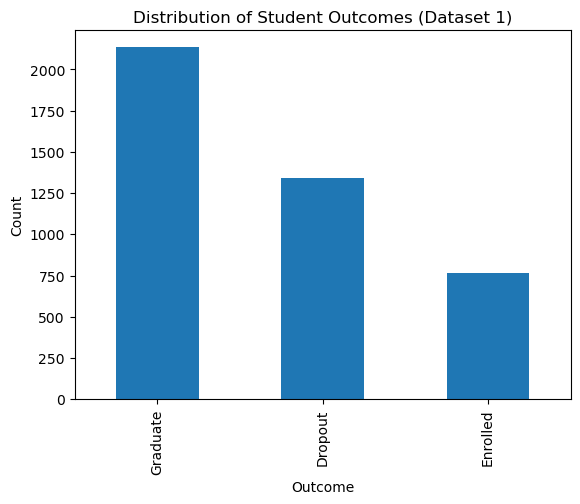

In [27]:
# Bar chart of student outcomes
data1_eda['Target'].value_counts().plot(kind='bar')
plt.title("Distribution of Student Outcomes (Dataset 1)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

We can see that in this specific dataset, there is a large number of dropout students when we compare it to the two other groups. When cleaning out the data, there was a noticeable number of lower pass rates and GPAs, so it's no surprise that this dataset has more emphasis on dropout students. This simply provides us with an idea of what this dataset will look like for the rest of our visualizations.

#### Predictor Comparison by Target

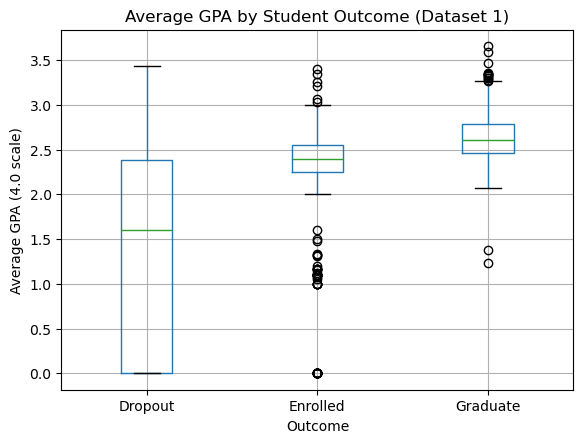

In [34]:
# Average GPA by outcome
data1_eda.boxplot(column='Avg_Gpa', by='Target')

plt.title("Average GPA by Student Outcome (Dataset 1)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Average GPA (4.0 scale)")

plt.show()

The visual is fairly self-explanatory: dropout students have a lower GPA distribution than graduating students. Enrolled students have a higher distribution, but it contains more outliers since this group could contain students who are doing well in their studies, and those who are struggling. Graduate students have the highest distribution, which makes sense, as those with better grades become graduate students.

Based on these visualizations, though, we can tell that there is a correlation between early academic GPA and the probability of a student dropping out. Those with lower GPAs at the start of their academic careers are more likely to drop out, but it's not always the case. As we can see in the visual, there are plenty of outliers with a low GPA below a 2.0 in both the enrolled and graduate groups. 

So while there is a strong relationship between first-year grades and eventual dropout rates, we can see that there are cases where students can overcome and continue their studies. In rare cases, students with low GPAs can still graduate, showing us that even if early academic performance has an influence on the probability of dropouts, students can always catch up and continue to pursue their academic careers despite early setbacks. 


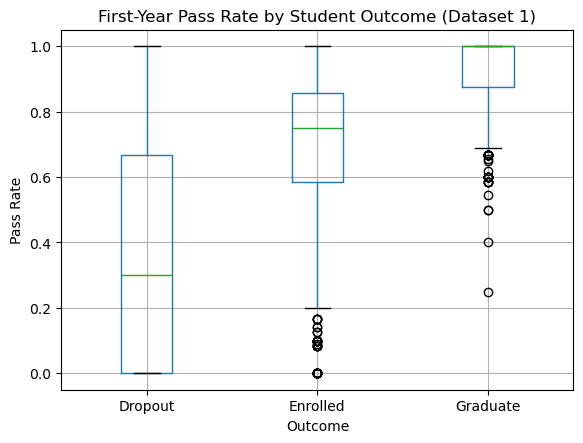

In [35]:
# Pass rate by outcome
data1_eda.boxplot(column='Pass_Rate', by='Target')

plt.title("First-Year Pass Rate by Student Outcome (Dataset 1)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Pass Rate")

plt.show()

This distribution shows a weaker correlation between pass rate and the probability of drop rate. While there exists a trend of graduates having a higher overall pass rate, there are plenty of outliers where the pass rate overlaps with that of the dropout group. Pass rate alone doesn't influence how likely a student is to drop out since failing courses is a normal part of higher education.

Failing courses and overcoming them is common, as seen in the visual, showing that while students could have a lower pass rate in courses, it's definitely possible to still succeed. 


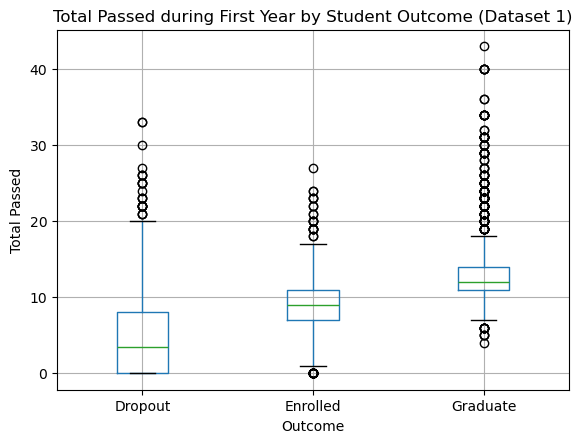

In [36]:
# Total passed by outcome
data1_eda.boxplot(column='Total_Passed', by='Target')

plt.title("Total Passed during First Year by Student Outcome (Dataset 1)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Total Passed")

plt.show()

We can see that the number of credits passed in the first year shows that it has some influence on drop out rate. Graduate students will have a higher number of passed credits, but it is interesting how there are plenty of outliers in the dropout group that pass just as many credits as those in the graduate group. It goes to show that there are plenty of other factors that could affect students who academically succeed in their first year, but later struggle due to burnout and eventually drop out. 

#### Risk Stratification/Categorization Plots

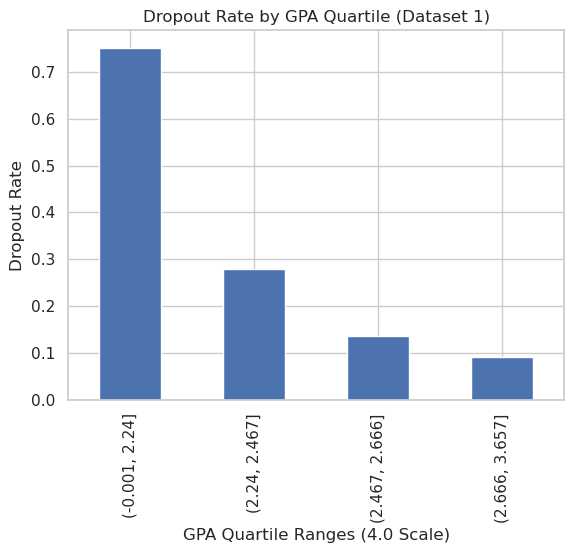

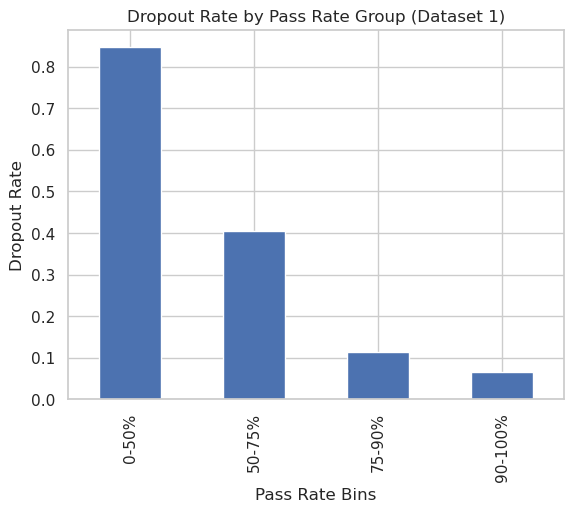

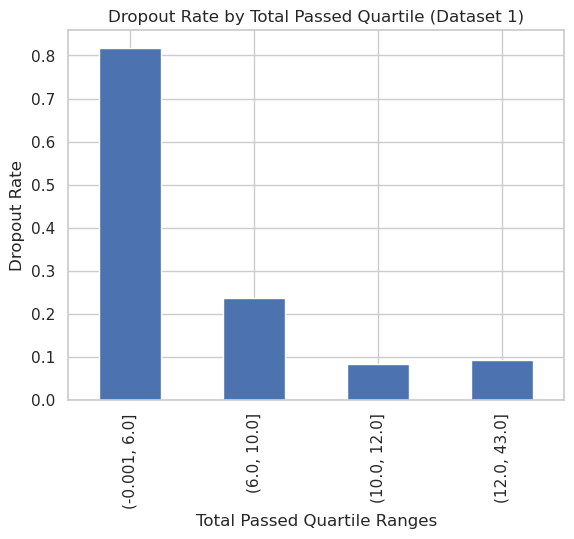

In [55]:
# Construct Dropout Binary Target
data1_eda['Dropout_Binary'] = (data1_eda['Target'] == 'Dropout').astype(int)

# GPA Quartiles
data1_eda['GPA_Quartile'] = pd.qcut(data1_eda['Avg_Gpa'], 4)

gpa_dropout_1 = data1_eda.groupby('GPA_Quartile', observed=False)['Dropout_Binary'].mean()

gpa_dropout_1.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Average GPA Quartile Ranges (4.0 Scale)")
plt.title("Dropout Rate by GPA Quartile (Dataset 1)")
plt.show()

# Pass Rate Groups (manual bins)
bins = [0, 0.5, 0.75, 0.9, 1.0]
labels = ["0-50%", "50-75%", "75-90%", "90-100%"]

data1_eda['PassRate_Group'] = pd.cut(
    data1_eda['Pass_Rate'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

passrate_dropout_1 = data1_eda.groupby('PassRate_Group', observed=False)['Dropout_Binary'].mean()

passrate_dropout_1.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Pass Rate Bins")
plt.title("Dropout Rate by Pass Rate Group (Dataset 1)")
plt.show()

data1_eda['TotalPassed_Quartile'] = pd.qcut(
    data1_eda['Total_Passed'],
    4,
    duplicates='drop'
)

totalpassed_dropout_1 = data1_eda.groupby('TotalPassed_Quartile', observed=False)['Dropout_Binary'].mean()

totalpassed_dropout_1.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Total Passed Quartile Ranges")
plt.title("Dropout Rate by Total Passed Quartile (Dataset 1)")
plt.show()

There is a decrease in dropout rate (for the most part) that can be seen in the number of credits passed and the overall pass rate. Students who have a solid foundation at the start of their academic careers are usually set for the rest of their university, with a stronger foundation resulting in a lower dropout rate. 

One odd thing in this graph is that there is a marginally higher rate of dropout for those who pass more credits in the uppermost quartile compared to the next quartile. It seems that at this point that dropout rates are indistinguishable past a certain amount of completed credits (around 10 credits at this school).

#### Joint Relationship

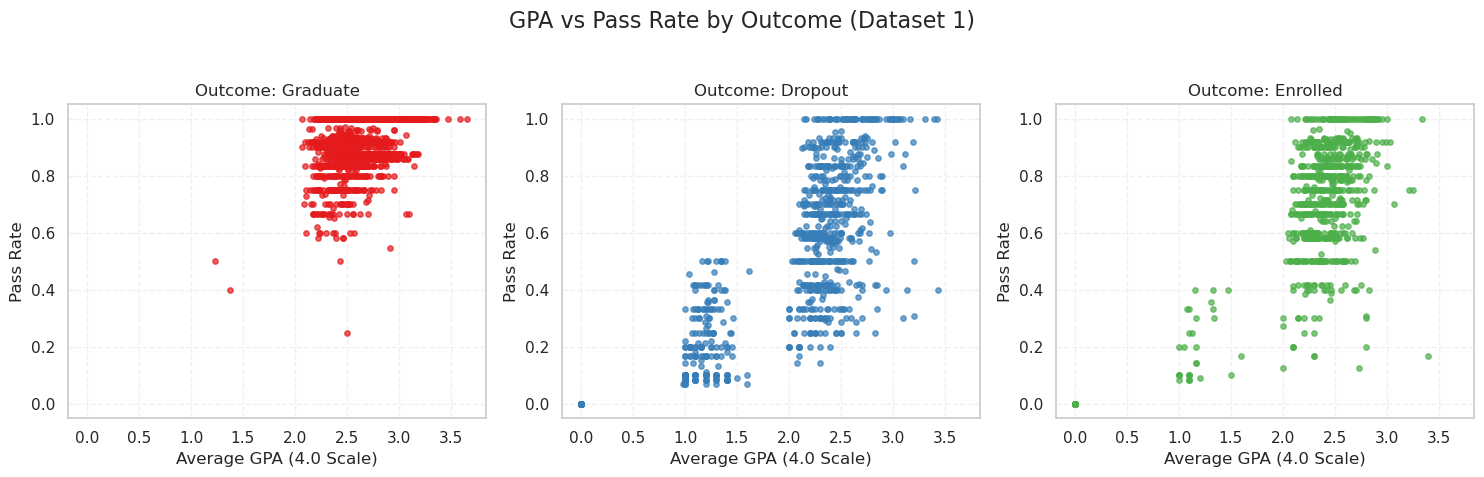

In [71]:
## Scatter plot for GPA and Pass Rate
colors = ['#e41a1c', '#377eb8', '#4daf4a']  # Red, Blue, Green
outcomes = data1_eda['Target'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, outcome in enumerate(outcomes):
    subset = data1_eda[data1_eda['Target'] == outcome]
    
    axes[i].scatter(
        subset['Avg_Gpa'], 
        subset['Pass_Rate'], 
        alpha=0.7, 
        s=15,           
        color=colors[i],   
        label=outcome
    )
    
    axes[i].set_title(f"Outcome: {outcome}")
    axes[i].set_xlabel("Average GPA (4.0 Scale)")
    axes[i].tick_params(labelleft=True) 
    axes[i].set_ylabel("Pass Rate")
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle("GPA vs Pass Rate by Outcome (Dataset 1)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('scatter_subplots_final_1.png')

This visual tells us that essentially all graduate students have a bare minimum of a 2.0 GPA, which makes sense since this is usually the standard minimum requirement for graduation, but we can see again that while a high pass rate is a pattern among graduating students, students enrolled and graduating still fail some courses and gravitate towards the lower performing region (down and left). 

#### Correlation

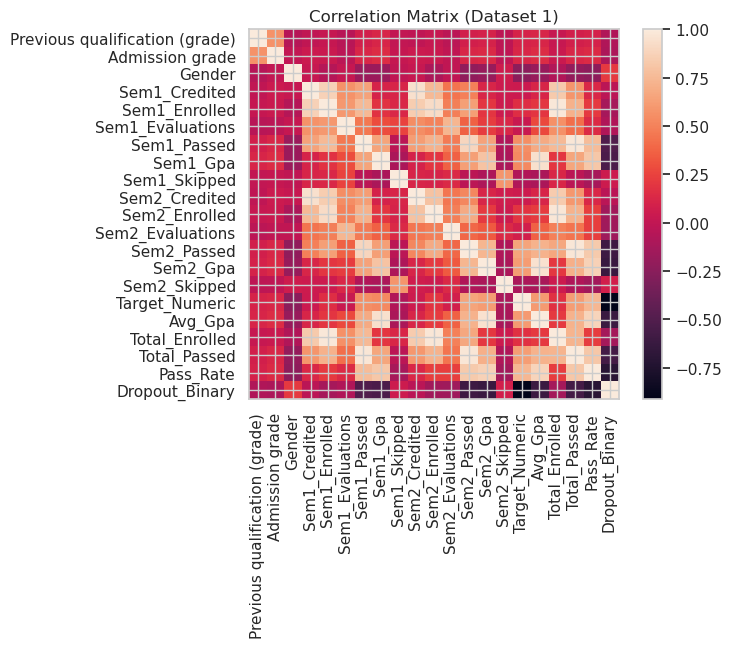

Target_Numeric                   -0.911470
Pass_Rate                        -0.699058
Sem2_Gpa                         -0.619417
Avg_Gpa                          -0.606650
Sem2_Passed                      -0.597128
Total_Passed                     -0.563741
Sem1_Gpa                         -0.527949
Sem1_Passed                      -0.501151
Sem2_Evaluations                 -0.152758
Sem2_Enrolled                    -0.144043
Total_Enrolled                   -0.133748
Sem1_Enrolled                    -0.120233
Admission grade                  -0.095885
Previous qualification (grade)   -0.080175
Sem1_Evaluations                 -0.079625
Sem2_Credited                    -0.031109
Sem1_Credited                    -0.027104
Sem1_Skipped                      0.057603
Sem2_Skipped                      0.083936
Gender                            0.209402
Dropout_Binary                    1.000000
Name: Dropout_Binary, dtype: float64

In [58]:
## Plot correlation matrix
numeric = data1_eda.select_dtypes(include='number')
corr = numeric.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Dataset 1)")
plt.show()

## Rank variables from most negative to most positive correlation with dropout
corr['Dropout_Binary'].sort_values()

The correlation matrix reveals strong negative associations between dropout status and academic performance indicators such as GPA, pass rate, and total credits passed.  Among academic performance variables, *Pass_Rate* exhibits the strongest negative correlation with dropout (r = -0.699), followed by second-semester GPA and the yearly average GPA.  Taking a look at the correlation matrix, many performance variables (particularly those related to the semester credits/pass rate) are highly intercorrelated, so careful predictor variable selection will be required to avoid redundancy and unstable coefficient estimates.

Note: *target_numeric* has an extremely high correlation because it’s basically encoding the same outcome information as *Dropout_Binary*. So it’s another version of the target and not a predictor in our analysis. Hence, we are not going to include it in our modeling.

#### Dataset 2 EDA

This section contains the cleaned-out version of dataset 2 and an analysis of it, filled with calculations, visualizations, and commentary. This section follows the exact methodology from the Dataset 1 EDA. 

In [59]:
data2_eda = pd.read_csv('data/02-processed/university_dropout_cleaned.csv', sep=';')
data2_eda

,Credits_Passed_Exam,Credits_Passed_Special,Credits_Internship_Enrolled,Sem1_Enrolled,Sem2_Enrolled,Sem1_Passed,Sem2_Passed,GPA,target_numeric,target
0,42.0,0.0,0.0,30.0,30.0,12.0,30.0,4.811111,2.0,Graduate
1,60.0,0.0,0.0,9.0,12.0,9.0,12.0,6.787500,2.0,Graduate
2,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.000000,2.0,Graduate
3,42.0,0.0,0.0,30.0,30.0,12.0,30.0,5.588889,2.0,Graduate
4,42.5,0.0,9.5,37.5,18.0,21.0,12.0,6.733333,2.0,Graduate
...,...,...,...,...,...,...,...,...,...,...
3833,0.0,60.0,0.0,19.5,16.5,0.0,0.0,3.700000,0.0,Dropout
3834,60.0,0.0,0.0,30.0,30.0,30.0,30.0,5.455556,2.0,Graduate
3835,48.0,0.0,0.0,32.0,28.0,32.0,16.0,8.321429,2.0,Graduate
3836,0.0,0.0,0.0,19.5,22.5,0.0,0.0,0.000000,2.0,Graduate


In [60]:
## Convert GPA column to US scale
max_span = 10.0
min_span = 0.0
max_usa = 4.0

data2_eda['GPA'] = (data2_eda['GPA'] / max_span) * max_usa

In [61]:
## Totaling up enrolled and passed credits for both semesters, including a ratio between the two

data2_eda['Total_Enrolled'] = data2_eda['Sem1_Enrolled'] + data2_eda['Sem2_Enrolled']
data2_eda['Total_Passed'] = data2_eda['Sem1_Passed'] + data2_eda['Sem2_Passed']
data2_eda['Pass_Rate'] = data2_eda['Total_Passed']/data2_eda['Total_Enrolled']

print(data2_eda[['Total_Enrolled','Total_Passed', 'Pass_Rate']].head(100))
data2_eda

    Total_Enrolled  Total_Passed  Pass_Rate
0             60.0          42.0   0.700000
1             21.0          21.0   1.000000
2             36.0           0.0   0.000000
3             60.0          42.0   0.700000
4             55.5          33.0   0.594595
..             ...           ...        ...
95            30.0          30.0   1.000000
96            60.0          60.0   1.000000
97            43.5          43.5   1.000000
98            60.0          60.0   1.000000
99            36.0           0.0   0.000000

[100 rows x 3 columns]


,Credits_Passed_Exam,Credits_Passed_Special,Credits_Internship_Enrolled,Sem1_Enrolled,Sem2_Enrolled,Sem1_Passed,Sem2_Passed,GPA,target_numeric,target,Total_Enrolled,Total_Passed,Pass_Rate
0,42.0,0.0,0.0,30.0,30.0,12.0,30.0,1.924444,2.0,Graduate,60.0,42.0,0.700000
1,60.0,0.0,0.0,9.0,12.0,9.0,12.0,2.715000,2.0,Graduate,21.0,21.0,1.000000
2,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.000000,2.0,Graduate,36.0,0.0,0.000000
3,42.0,0.0,0.0,30.0,30.0,12.0,30.0,2.235556,2.0,Graduate,60.0,42.0,0.700000
4,42.5,0.0,9.5,37.5,18.0,21.0,12.0,2.693333,2.0,Graduate,55.5,33.0,0.594595
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3833,0.0,60.0,0.0,19.5,16.5,0.0,0.0,1.480000,0.0,Dropout,36.0,0.0,0.000000
3834,60.0,0.0,0.0,30.0,30.0,30.0,30.0,2.182222,2.0,Graduate,60.0,60.0,1.000000
3835,48.0,0.0,0.0,32.0,28.0,32.0,16.0,3.328571,2.0,Graduate,60.0,48.0,0.800000
3836,0.0,0.0,0.0,19.5,22.5,0.0,0.0,0.000000,2.0,Graduate,42.0,0.0,0.000000


In [62]:
## Create binary variable for target
data2_eda['Dropout_Binary'] = (data2_eda['target'] == 'Dropout').astype(int)

#### Outcome Distribution

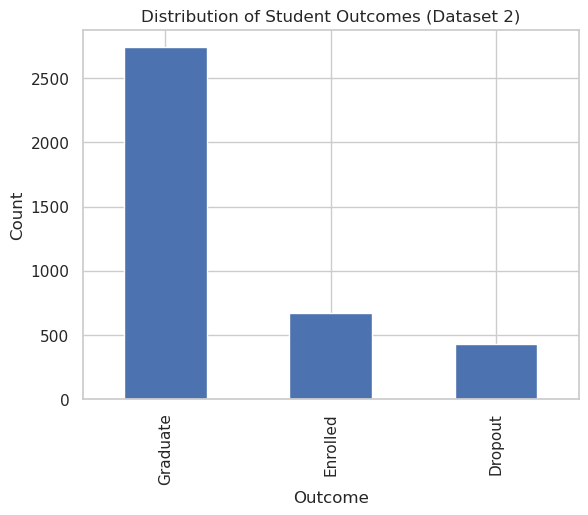

In [49]:
## Display bar chart of student outcomes
data2_eda['target'].value_counts().plot(kind='bar')
plt.title("Distribution of Student Outcomes (Dataset 2)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

We can see that in this specific dataset, dropout students are much less prevalent, only about 10% to 15% of the dataset, so this study conducted seemed to have more emphasis on students who were academically succeeding compared to the first dataset.


#### Predictor Comparison by Target

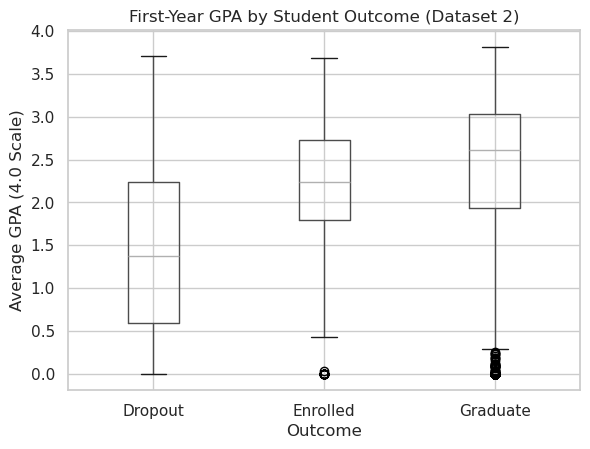

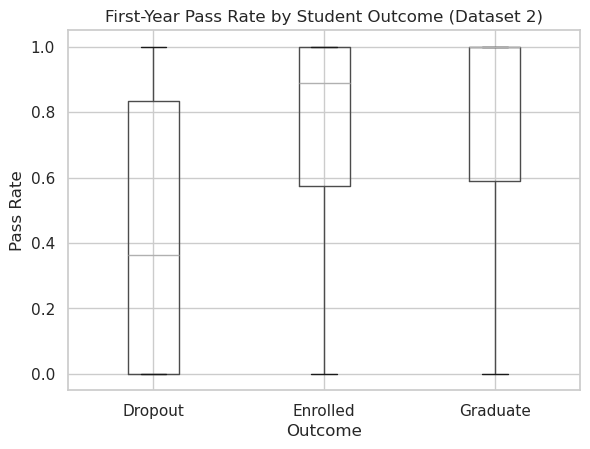

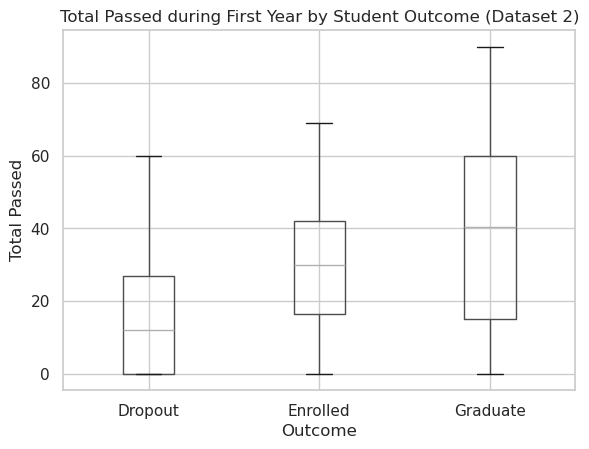

In [51]:
## GPA by target
data2_eda.boxplot(column='GPA', by='target')
plt.title("First-Year GPA by Student Outcome (Dataset 2)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Average GPA (4.0 Scale)")
plt.show()

## Pass rate by target
data2_eda.boxplot(column='Pass_Rate', by='target')
plt.title("First-Year Pass Rate by Student Outcome (Dataset 2)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Pass Rate")
plt.show()

## Total passed by target
data2_eda.boxplot(column='Total_Passed', by='target')
plt.title("Total Passed during First Year by Student Outcome (Dataset 2)")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Total Passed")
plt.show()

The visual shows distributions with plenty of similarities to the first dataset, showing us that there is a trend where more passed credits, a higher GPA, and a higher pass rate in the first year have a strong correlation with a student who ends up graduating. The only difference between these two analyseses are the outliers in each group, where dataset 2 seems to be more uniform (less variability) with much fewer outliers. The outliers in the graduate group of the GPA plot are also intriguing since it shows that there were a handful of graduates with very low GPAs in their first year who managed to graduate.

So while there is a solid correlation between these metrics of early academic performance and graduating, there are plenty of cases that go against this trend and show that students can either do poorly at the start in terms of grades and still succeed, or pass a majority of their classes their first year, but ultimately drop out due to external factors. 


#### Risk Stratification/Categorization Plots

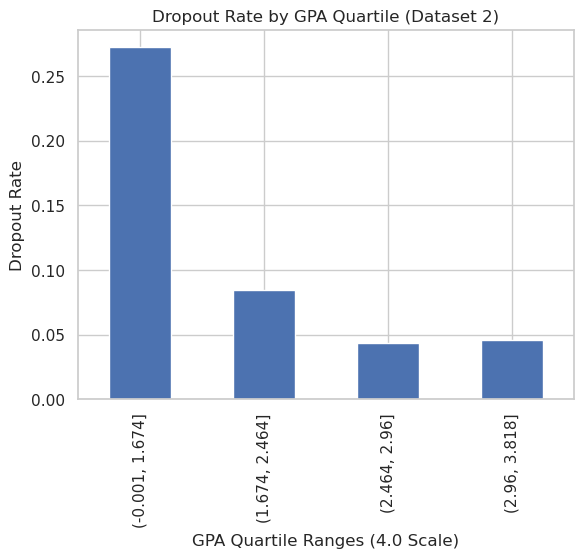

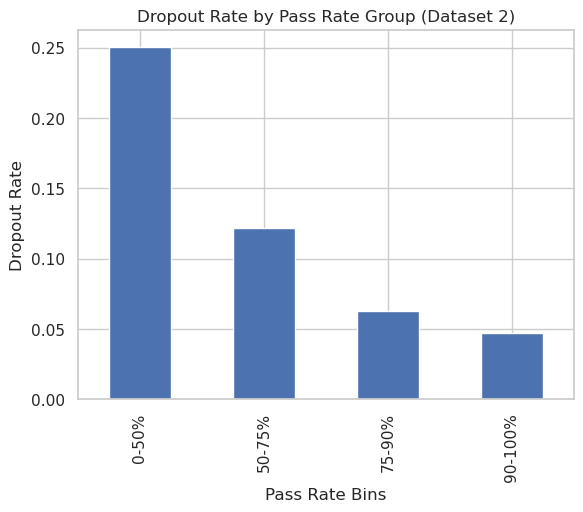

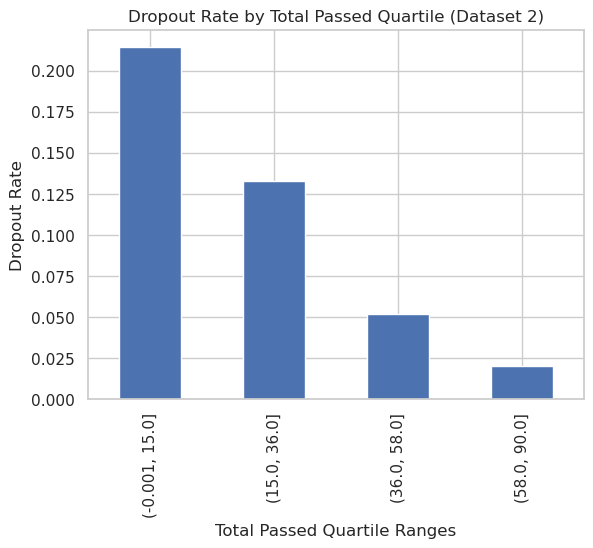

In [56]:
# GPA Quartiles
data2_eda['GPA_Quartile'] = pd.qcut(data2_eda['GPA'], 4)

gpa_dropout = data2_eda.groupby('GPA_Quartile', observed=False)['Dropout_Binary'].mean()

gpa_dropout.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Average GPA Quartile Ranges (4.0 Scale)")
plt.title("Dropout Rate by GPA Quartile (Dataset 2)")
plt.show()

# Pass Rate Groups (manual bins)
bins = [0, 0.5, 0.75, 0.9, 1.0]
labels = ["0-50%", "50-75%", "75-90%", "90-100%"]

data2_eda['PassRate_Group'] = pd.cut(
    data2_eda['Pass_Rate'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

passrate_dropout = data2_eda.groupby('PassRate_Group', observed=False)['Dropout_Binary'].mean()

passrate_dropout.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Pass Rate Bins")
plt.title("Dropout Rate by Pass Rate Group (Dataset 2)")
plt.show()

data2_eda['TotalPassed_Quartile'] = pd.qcut(
    data2_eda['Total_Passed'],
    4,
    duplicates='drop'
)

totalpassed_dropout = data2_eda.groupby('TotalPassed_Quartile', observed=False)['Dropout_Binary'].mean()

totalpassed_dropout.plot(kind='bar')
plt.ylabel("Dropout Rate")
plt.xlabel("Total Passed Quartile Ranges")
plt.title("Dropout Rate by Total Passed Quartile (Dataset 2)")
plt.show()

We see the general trend similar to the first dataset where dropout drops as academic performance indicators are higher.  foundation resulting in a lower dropout rate. The only odd thing we see in this is in the GPA plot, where dropout rate is about the same for the two upper quartiles of students with higher GPAs, which could further emphasize the effect of burnout and how having high grades at the start isn't as strong an indicator of graduation rate. 

This could also be the fact that courses in the first year are lower in difficulty, so students have an easier time at the start, but find themselves struggling with more difficult classes later on. 


#### Joint Relationship

In [68]:
# for outcome in data2_eda['target'].unique():
#     subset = data2_eda[data2_eda['target'] == outcome]
#     plt.scatter(subset['GPA'], subset['Pass_Rate'], alpha=0.5, label=outcome)

# plt.xlabel("GPA")
# plt.ylabel("Pass Rate")
# plt.legend()
# plt.title("GPA vs Pass Rate by Outcome")
# plt.show()

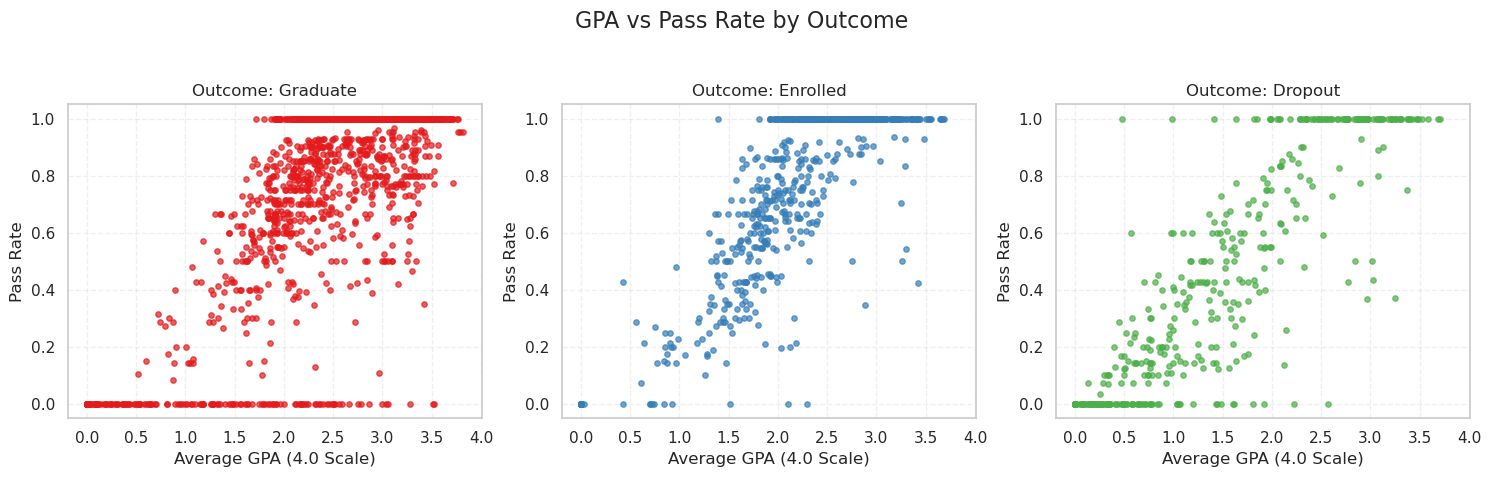

In [67]:
## Scatter plot for GPA and Pass Rate
colors = ['#e41a1c', '#377eb8', '#4daf4a']  # Red, Blue, Green
outcomes = data2_eda['target'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, outcome in enumerate(outcomes):
    subset = data2_eda[data2_eda['target'] == outcome]
    
    axes[i].scatter(
        subset['GPA'], 
        subset['Pass_Rate'], 
        alpha=0.7, 
        s=15,           
        color=colors[i],   
        label=outcome
    )
    
    axes[i].set_title(f"Outcome: {outcome}")
    axes[i].set_xlabel("Average GPA (4.0 Scale)")
    axes[i].tick_params(labelleft=True) 
    axes[i].set_ylabel("Pass Rate")
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.suptitle("GPA vs Pass Rate by Outcome", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('scatter_subplots_final.png')

The scatter plots of GPA and pass rate reveals a clear positive association between the two performance measures, as expected, since both reflect academic performance. However, GPA captures performance quality while pass rate reflects course completion success, suggesting they may contribute distinct predictive information. Dropout students are concentrated in the lower-performance (bottom left) region, particularly among students with both low GPA and low pass rates. Graduates cluster in the higher performance (upper-right) region, characterized by strong grades and high course completion rates. The visible clustering supports the hypothesis that early academic performance is strongly associated with dropout risk and suggests that combining GPA and pass rate may improve predictive modeling.

#### Correlation

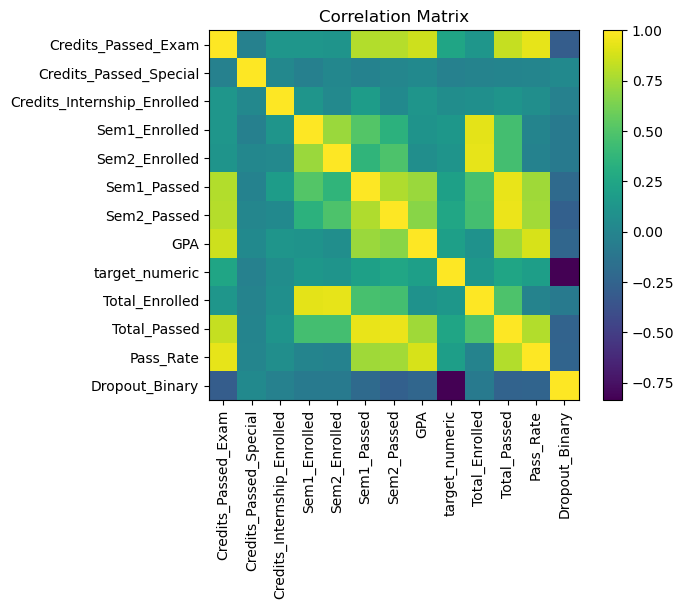

target_numeric                -0.835155
Credits_Passed_Exam           -0.294187
Sem2_Passed                   -0.273347
Total_Passed                  -0.249933
Pass_Rate                     -0.244789
GPA                           -0.228474
Sem1_Passed                   -0.197419
Total_Enrolled                -0.085442
Sem2_Enrolled                 -0.081549
Sem1_Enrolled                 -0.077064
Credits_Internship_Enrolled   -0.027440
Credits_Passed_Special         0.034894
Dropout_Binary                 1.000000
Name: Dropout_Binary, dtype: float64

In [46]:
## Plot correlation matrix
numeric = data2_eda.select_dtypes(include='number')
corr = numeric.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

## Rank variables from most negative to most positive correlation with dropout
corr['Dropout_Binary'].sort_values()

The correlation matrix reveals strong negative associations between dropout status and academic performance indicators such as GPA, pass rate, and total credits passed.  Among academic performance variables, *Credits_Passed_Exam* exhibits the strongest negative correlation with dropout (r = -0.29), followed by second-semester credits passed and total credits passed. While GPA is also negatively associated with dropout, the magnitude of correlation suggests that course completion volume may be slightly more predictive of attrition than grade quality alone. However, many performance variables are highly intercorrelated. This suggests that careful variable selection will be necessary in subsequent predictive modeling to avoid redundancy and unstable coefficient estimates.

Note: *target_numeric* has an extremely high correlation because it’s basically encoding the same outcome information as *Dropout_Binary*. So it’s another version of the target and not a predictor in our analysis. Hence, we are not going to include it in our modeling.

## Ethics 

### A. Data Collection
 - [ ] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> We will have to read through the paper that originally collected this data and determine whether the data was appropriately collected and whether or not students were given adequate warning as to what was being collected.

 - [ ] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> The data was collected by serveral researchers in Portugal for the purposes of their research as such we will have to consider the bias that the researchers possibly could have introduced through the data collection and the biases that may originate from the data being collected in portugal.

 - [ ] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> Although we currently believe the data we have is anonymous we will need to re-examine the source and determine if there is any additional information that needs to be censored.

 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> We will have to perform analysis where we include and exclude gender, our protected groups, to see if doing so results some form of algorithmic bias so that we can hopefully correct for it and provide an unbiased collection of data.


### B. Data Storage
 - [ ] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Since we are not generating any new data and instead using an already created data set there will not be anything for us to hide, although we could hide the conclusions of our data at the end of the analysis.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> The data was already collected by others so we cannot support this for the original participants.

 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> The data was already collected by others so we cannot support this for the original participants.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> While we intend for our analysis to be qualitative, we could reach out to experts in education inequity to get a better handle of how accurate our analysis is from their persepctive.

 - [ ] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Since the data has many data points that are discrete, many that maybe would have been better served being continuous, we will take specific caution towards determining which of these can be used and determining how best to interpret and use them.

 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We will have to ensure that different data points are correctly weighted when determining such that we are not forcing our analysis towards a particulur conclusion.

 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> Since the data does not have any specific PII, we do not anticipate having to do anything specific for our analysis.

 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We intend to have a very well formatted and easily readable jupyter notebook to ensure that it is easy to see what we did thus making it easily auditable.

### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> We will have to be careful with the careers or the parents as these may be proxies that result in us finding that socioeconomic status is the sole determinant of success.

 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> We will have to test to see if the model is appropriatley fair accross the binary grouping that they have in the data like rural vs urban addresses which do not actually make up an address and rather just have a one value for rural and another for urban.

 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> Since we are intending to optimize to find out what factors can be used as predictors to determine if a students chance of dropping out we need to be cautious that this can result in false positives and negatives, if our model places certain students in the dropout or graduate pile this could change how money is spent in a school which we would like to avoid.

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> We hope to make the model very clear and to explain all of the analysis that we do in the jupyter notebook so that we can go back and understand and justify the decision that the model made.

 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We will have to ensure that we communicate the various limitations that are present with our data and analysis so that who ever desires to look at our model understands the potential flaws in our analysis and modeling.

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> We do not yet have a clear plan for how to monitor the model after it is deployed but, if it were to be used, the users would likely have to be careful with how they use it when modifying school programs and spending.

 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> No we have not discussed this, but it would be difficult to address if it were to happen since we do not know the respondants and are geographically very far away from them.

 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> We think that we would be able to just turn off the script. In the end our analysis will not continue to aggregate more data so we do not anticipate any issues that require deleting the model.

 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> We have yet to take steps towards this, but we need to ensure that the models results cannot be misinterpreted and abused for someone elses purpose.


## Team Expectations 

* Our primary form of communication is Discord. We expect all members to respond to and/or acknowledge all members' messages within one day. We plan to meet once a week, either in person or virtually, on Monday afternoons.
We expect all members to maintain a respectful and polite tone when communicating with others. Don't be mean, even if there are disagreements. We want to keep an open mind, value everyone's opinions equally, and be proactive in brainstorming solutions for the good of the team. For example, if there are conflicting perspectives, we can communicate our opinions by saying "I don't think moving forward with X is within our group's best interest because of Y. Instead, we should explore Z."

* Ideally, we want to make unanimous decisions. However, this is not always possible, so we will default to majority vote rules. If a member does not reply or acknowledge a proposal/message within a day, we can move forward with their input. Team members can react to Discord messages as a form of acknowledgement, especially if they're unable to respond immediately.

* Every member will get first-hand experience pertaining to all aspects of our project. Having members do a little bit of everything will ensure that we are all able to develop our skills individually. We will delegate tasks during our weekly meetings and send a message in our "to-do" channel on Discord.

* If there any issues, we expect each other to speak up EARLY before the deadline. As a general rule of thumb, we expect members to reach out at least a day or two PLUS the expected time it takes to complete the specific task if there are any issues or concerns.


## Project Timeline Proposal

Tentative timeline that is subject to change throughout the rest of the quarter

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 3/4  | 3 PM  | Look at feedback and take a look at other EDAs; Discuss feedback and assign work for EDA checkpoint |
| 3/9  | 2PM  | Look at feedback and prepare for final portion of project | Discuss feedback and final touches |
| 3/16  | 2PM  | Work on Final Project | Prepare Final video and any final changes to before submitting |